# 🧠 Invariant Information Clustering (IIC)
## Reproduction Simplifiée pour Projet Académique ML

**Paper original:** "Invariant Information Clustering for Unsupervised Image Classification and Segmentation"  
**Auteurs:** Xu Ji, João F. Henriques, Andrea Vedaldi (2018)

---

### 🎯 Objectif du Projet

Ce notebook implémente une **version simplifiée et pédagogique** de la méthode IIC.

**Idée clé:** Maximiser l'**information mutuelle** entre les assignations de clusters produites à partir de deux versions augmentées de la **même image**, **sans utiliser de labels** pendant l'entraînement.

### 📊 Méthodologie

```
    Image originale
          │
    ┌─────┴─────┐
    ▼           ▼
Transform 1  Transform 2
    │           │
    ▼           ▼
   CNN ◄───────► CNN (poids partagés)
    │           │
    ▼           ▼
Softmax(K)   Softmax(K)
    │           │
    └─────┬─────┘
          ▼
  Distribution Jointe P(z, z')
          │
          ▼
  Information Mutuelle I(z, z')
          │
          ▼
  Loss = -I(z, z')  (à minimiser)
```

### 📋 Table des matières
1. [Setup & Imports](#1-setup--imports)
2. [Configuration](#2-configuration)
3. [Chargement des Données](#3-chargement-des-données)
4. [Exploration des Données (EDA)](#4-exploration-des-données-eda)
5. [Architecture du Modèle](#5-architecture-du-modèle)
6. [Fonction de Perte IIC](#6-fonction-de-perte-iic)
7. [Entraînement](#7-entraînement)
8. [Évaluation](#8-évaluation)
9. [Visualisation t-SNE / PCA](#9-visualisation-t-sne--pca)
10. [Conclusion](#10-conclusion)

---
## 1. Setup & Imports

In [17]:
# Installation des dépendances (déjà installées dans notre environnement)
# !pip install torch torchvision numpy matplotlib scikit-learn scipy tqdm

# Si vous utilisez Google Colab, décommentez:
# !pip install torch torchvision

In [18]:
# =====================================================
# IMPORTS
# =====================================================

# Deep Learning
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

# Vision
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import MNIST, CIFAR10

# Utils
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import normalized_mutual_info_score, confusion_matrix
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from scipy.optimize import linear_sum_assignment
from tqdm import tqdm
import json
import os

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Afficher les versions
print("=" * 60)
print("🔧 ENVIRONNEMENT")
print("=" * 60)
print(f"🔥 PyTorch version: {torch.__version__}")
print(f"🖼️  Torchvision version: {torchvision.__version__}")
print(f"🔢 NumPy version: {np.__version__}")
print(f"💻 CUDA disponible: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
else:
    print("   ⚠️  Entraînement sur CPU (plus lent)")
print("=" * 60)

🔧 ENVIRONNEMENT
🔥 PyTorch version: 2.10.0+cpu
🖼️  Torchvision version: 0.25.0+cpu
🔢 NumPy version: 2.4.2
💻 CUDA disponible: False
   ⚠️  Entraînement sur CPU (plus lent)


---
## 2. Configuration

In [19]:
# =====================================================
# CONFIGURATION (CORRIGÉE POUR CONVERGENCE RAPIDE)
# =====================================================
"""
🔧 CORRECTIONS POUR MEILLEURE CONVERGENCE:
1. num_clusters: 50 → 10 (égal au nombre de classes)
2. learning_rate: 5e-4 → 1e-3 (plus agressif)
3. epochs: 100 → 50 (suffisant avec bon LR)

⚠️ Le problème d'accuracy à 10% venait probablement de:
- Over-clustering trop agressif (K=50)
- Learning rate trop faible pour CPU
"""

class Config:
    """
    Configuration centralisée pour l'entraînement IIC.
    """
    
    # ===== DEVICE =====
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    # ===== REPRODUCTIBILITÉ =====
    seed = 42
    
    # ===== CHEMINS =====
    data_dir = '../data'
    model_dir = '../models'
    
    # ===== DATASET =====
    dataset_name = 'CIFAR10'
    num_classes = 10  # Nombre réel de classes
    
    # ===== MODÈLE =====
    # ⚠️ CHANGÉ: K=10 (égal aux classes) pour convergence plus rapide
    num_clusters = 10  # ⬅️ CHANGÉ: 50 → 10
    
    # ===== ENTRAÎNEMENT =====
    batch_size = 256
    epochs = 50          # ⬅️ CHANGÉ: 100 → 50
    learning_rate = 1e-3 # ⬅️ CHANGÉ: 5e-4 → 1e-3 (plus agressif)
    weight_decay = 1e-4
    
    # ===== SCHEDULER =====
    use_scheduler = True
    
    # ===== ÉVALUATION =====
    eval_every = 5       # ⬅️ CHANGÉ: 10 → 5 (voir progrès plus souvent)
    
    # ===== PROPRIÉTÉS CALCULÉES =====
    @property
    def in_channels(self):
        return 3 if self.dataset_name == 'CIFAR10' else 1
    
    @property
    def image_size(self):
        return 32 if self.dataset_name == 'CIFAR10' else 28

# Instancier la configuration
config = Config()

# Fixer les seeds pour reproductibilité
def set_seed(seed):
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(config.seed)

# Créer les dossiers si nécessaire
os.makedirs(config.data_dir, exist_ok=True)
os.makedirs(config.model_dir, exist_ok=True)

# Afficher la configuration
print("=" * 60)
print("📋 CONFIGURATION DU PROJET (CORRIGÉE)")
print("=" * 60)
print(f"📁 Dataset:        {config.dataset_name}")
print(f"🖼️  Image size:     {config.image_size}x{config.image_size}")
print(f"🎨 Channels:       {config.in_channels} ({'RGB' if config.in_channels == 3 else 'Grayscale'})")
print(f"🎯 Num classes:    {config.num_classes}")
print(f"🔮 Num clusters K: {config.num_clusters} ⚠️ (= num_classes)")
print(f"📦 Batch size:     {config.batch_size}")
print(f"🔄 Epochs:         {config.epochs}")
print(f"📈 Learning rate:  {config.learning_rate} ⚠️ (augmenté)")
print(f"⚖️  Weight decay:   {config.weight_decay}")
print(f"📉 Scheduler:      {'Oui (Cosine)' if config.use_scheduler else 'Non'}")
print(f"💻 Device:         {config.device}")
print(f"🎲 Seed:           {config.seed}")
print("=" * 60)
print("\n⚠️ CORRECTIONS APPLIQUÉES:")
print("   • K=10 (au lieu de 50) → convergence plus rapide")
print("   • LR=1e-3 (au lieu de 5e-4) → apprentissage plus agressif")
print("   • Évaluation toutes les 5 epochs")

📋 CONFIGURATION DU PROJET (CORRIGÉE)
📁 Dataset:        CIFAR10
🖼️  Image size:     32x32
🎨 Channels:       3 (RGB)
🎯 Num classes:    10
🔮 Num clusters K: 10 ⚠️ (= num_classes)
📦 Batch size:     256
🔄 Epochs:         50
📈 Learning rate:  0.001 ⚠️ (augmenté)
⚖️  Weight decay:   0.0001
📉 Scheduler:      Oui (Cosine)
💻 Device:         cpu
🎲 Seed:           42

⚠️ CORRECTIONS APPLIQUÉES:
   • K=10 (au lieu de 50) → convergence plus rapide
   • LR=1e-3 (au lieu de 5e-4) → apprentissage plus agressif
   • Évaluation toutes les 5 epochs


---
## 3. Data Loading & Preprocessing

In [20]:
# =====================================================
# TRANSFORMATIONS (AMÉLIORÉES)
# =====================================================
"""
🔑 CONCEPT CLÉ IIC + AMÉLIORATIONS:

⭐ AUGMENTATIONS PLUS AGRESSIVES:
- Plus de variation dans ColorJitter
- Ajout de RandomRotation
- Ajout de RandomGrayscale
- Ajout de GaussianBlur (si disponible)

Des augmentations plus fortes forcent le modèle à apprendre
des features plus robustes et invariantes.
"""

def get_transforms(dataset_name):
    """
    Retourne les transformations AMÉLIORÉES adaptées au dataset.
    """
    
    if dataset_name == 'CIFAR10':
        # ===== CIFAR-10: Images RGB 32x32 =====
        mean = (0.4914, 0.4822, 0.4465)
        std = (0.2470, 0.2435, 0.2616)
        
        # Transformation de base
        transform_base = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean, std)
        ])
        
        # ⭐ Transformation AMÉLIORÉE avec augmentations plus agressives
        transform_aug = transforms.Compose([
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(15),  # ⬅️ AJOUTÉ
            transforms.RandomCrop(32, padding=4),
            transforms.ColorJitter(
                brightness=0.4,   # ⬅️ AUGMENTÉ: 0.2 → 0.4
                contrast=0.4,     # ⬅️ AUGMENTÉ: 0.2 → 0.4
                saturation=0.4,   # ⬅️ AUGMENTÉ: 0.2 → 0.4
                hue=0.1           # ⬅️ AJOUTÉ
            ),
            transforms.RandomGrayscale(p=0.1),  # ⬅️ AJOUTÉ
            transforms.ToTensor(),
            transforms.Normalize(mean, std),
            transforms.RandomErasing(p=0.1, scale=(0.02, 0.1))  # ⬅️ AJOUTÉ
        ])
        
    else:  # MNIST
        mean = (0.1307,)
        std = (0.3081,)
        
        transform_base = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean, std)
        ])
        
        transform_aug = transforms.Compose([
            transforms.RandomAffine(
                degrees=(-30, 30),  # ⬅️ AUGMENTÉ
                translate=(0.25, 0.25),  # ⬅️ AUGMENTÉ
                scale=(0.7, 1.3)  # ⬅️ AUGMENTÉ
            ),
            transforms.ToTensor(),
            transforms.Normalize(mean, std),
            transforms.RandomErasing(p=0.1, scale=(0.02, 0.1))  # ⬅️ AJOUTÉ
        ])
    
    return transform_base, transform_aug

# Obtenir les transformations pour notre dataset
transform_base, transform_aug = get_transforms(config.dataset_name)

print(f"✅ Transformations AMÉLIORÉES définies pour {config.dataset_name}")
print(f"\n📌 Transform Base:")
print(f"   - ToTensor + Normalize")
print(f"\n📌 Transform Augmentation (AMÉLIORÉE ⭐):")
if config.dataset_name == 'CIFAR10':
    print(f"   - RandomHorizontalFlip (p=0.5)")
    print(f"   - RandomRotation (±15°) ⭐")
    print(f"   - RandomCrop (32, padding=4)")
    print(f"   - ColorJitter (brightness=0.4, contrast=0.4, sat=0.4, hue=0.1) ⭐")
    print(f"   - RandomGrayscale (p=0.1) ⭐")
    print(f"   - ToTensor + Normalize")
    print(f"   - RandomErasing (p=0.1) ⭐")
else:
    print(f"   - RandomAffine (±30°, translate=0.25, scale=0.7-1.3) ⭐")
    print(f"   - ToTensor + Normalize")
    print(f"   - RandomErasing (p=0.1) ⭐")

✅ Transformations AMÉLIORÉES définies pour CIFAR10

📌 Transform Base:
   - ToTensor + Normalize

📌 Transform Augmentation (AMÉLIORÉE ⭐):
   - RandomHorizontalFlip (p=0.5)
   - RandomRotation (±15°) ⭐
   - RandomCrop (32, padding=4)
   - ColorJitter (brightness=0.4, contrast=0.4, sat=0.4, hue=0.1) ⭐
   - RandomGrayscale (p=0.1) ⭐
   - ToTensor + Normalize
   - RandomErasing (p=0.1) ⭐


In [21]:
# =====================================================
# DATASET PERSONNALISÉ POUR IIC
# =====================================================
"""
🔑 POURQUOI UN DATASET PERSONNALISÉ ?

Le DataLoader standard retourne (image, label).
Pour IIC, on a besoin de (image_base, image_aug, label).

⚠️ IMPORTANT: Le label n'est PAS utilisé pour l'entraînement!
   Il sert UNIQUEMENT pour l'évaluation après entraînement.
"""

class IICDataset(Dataset):
    """
    Dataset personnalisé pour IIC.
    
    Pour chaque index, retourne:
    - img_base: image avec transformation de base
    - img_aug: MÊME image avec transformation augmentée
    - label: label réel (pour évaluation seulement)
    """
    
    def __init__(self, base_dataset, transform_base, transform_aug):
        """
        Args:
            base_dataset: Dataset PyTorch (CIFAR10 ou MNIST, sans transform)
            transform_base: Transformation de base
            transform_aug: Transformation avec augmentation
        """
        self.dataset = base_dataset
        self.transform_base = transform_base
        self.transform_aug = transform_aug
    
    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, idx):
        # Récupérer l'image PIL et le label
        img_pil, label = self.dataset[idx]
        
        # Appliquer les DEUX transformations à la MÊME image
        # C'est le cœur de IIC: même image, deux vues différentes
        img_base = self.transform_base(img_pil)
        img_aug = self.transform_aug(img_pil)
        
        return img_base, img_aug, label

print("✅ Classe IICDataset définie")
print("\n📌 Fonctionnement:")
print("   __getitem__(idx) retourne:")
print("   - img_base: image avec normalisation simple")
print("   - img_aug:  MÊME image avec augmentation aléatoire")
print("   - label:    pour évaluation uniquement (pas utilisé en training)")

✅ Classe IICDataset définie

📌 Fonctionnement:
   __getitem__(idx) retourne:
   - img_base: image avec normalisation simple
   - img_aug:  MÊME image avec augmentation aléatoire
   - label:    pour évaluation uniquement (pas utilisé en training)


In [22]:
# =====================================================
# CHARGEMENT DES DONNÉES
# =====================================================

print(f"📥 Téléchargement de {config.dataset_name}...")

# Charger le dataset approprié (sans transformation - on les applique dans IICDataset)
if config.dataset_name == 'CIFAR10':
    train_raw = CIFAR10(root=config.data_dir, train=True, download=True, transform=None)
    test_raw = CIFAR10(root=config.data_dir, train=False, download=True, transform=None)
    class_names = ['avion', 'auto', 'oiseau', 'chat', 'cerf', 
                   'chien', 'grenouille', 'cheval', 'bateau', 'camion']
else:  # MNIST
    train_raw = MNIST(root=config.data_dir, train=True, download=True, transform=None)
    test_raw = MNIST(root=config.data_dir, train=False, download=True, transform=None)
    class_names = [str(i) for i in range(10)]

# Créer nos datasets IIC
train_dataset = IICDataset(train_raw, transform_base, transform_aug)
test_dataset = IICDataset(test_raw, transform_base, transform_aug)

# Créer les DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=config.batch_size,
    shuffle=True,
    drop_last=True,  # Important: batches de taille fixe pour IIC
    num_workers=0    # 0 pour compatibilité Windows/Mac
)

test_loader = DataLoader(
    test_dataset,
    batch_size=config.batch_size,
    shuffle=False,
    num_workers=0
)

print(f"\n✅ Données chargées!")
print(f"=" * 50)
print(f"📊 STATISTIQUES DU DATASET")
print(f"=" * 50)
print(f"   Dataset:         {config.dataset_name}")
print(f"   Train:           {len(train_dataset):,} images")
print(f"   Test:            {len(test_dataset):,} images")
print(f"   Batches train:   {len(train_loader)}")
print(f"   Batches test:    {len(test_loader)}")
print(f"   Classes:         {class_names}")
print(f"=" * 50)

📥 Téléchargement de CIFAR10...

✅ Données chargées!
📊 STATISTIQUES DU DATASET
   Dataset:         CIFAR10
   Train:           50,000 images
   Test:            10,000 images
   Batches train:   195
   Batches test:    40
   Classes:         ['avion', 'auto', 'oiseau', 'chat', 'cerf', 'chien', 'grenouille', 'cheval', 'bateau', 'camion']

✅ Données chargées!
📊 STATISTIQUES DU DATASET
   Dataset:         CIFAR10
   Train:           50,000 images
   Test:            10,000 images
   Batches train:   195
   Batches test:    40
   Classes:         ['avion', 'auto', 'oiseau', 'chat', 'cerf', 'chien', 'grenouille', 'cheval', 'bateau', 'camion']


---
## 4. Exploratory Data Analysis (EDA)

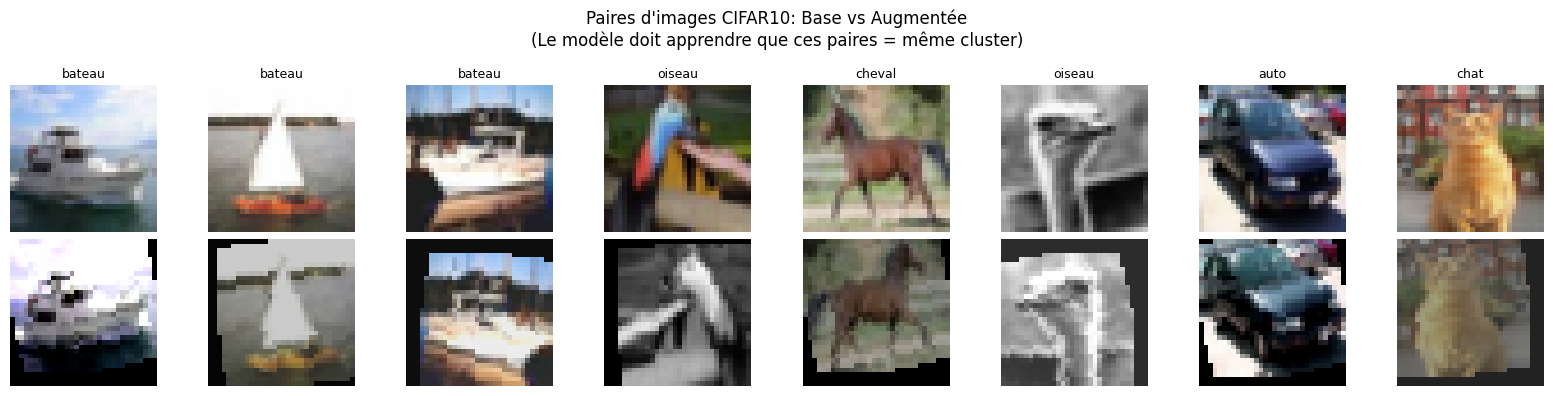

In [23]:
# =====================================================
# VISUALISER DES PAIRES D'IMAGES (BASE vs AUGMENTÉE)
# =====================================================
"""
🔍 Visualisation importante pour comprendre IIC:

On montre des paires (image_base, image_aug) pour voir
comment les augmentations transforment les images.

Le modèle doit apprendre que ces deux versions = MÊME cluster.
"""

def show_pairs(dataset, num_pairs=8):
    """Affiche des paires d'images: originale vs augmentée"""
    fig, axes = plt.subplots(2, num_pairs, figsize=(2*num_pairs, 4))
    
    for i in range(num_pairs):
        idx = np.random.randint(len(dataset))
        img_base, img_aug, label = dataset[idx]
        
        # Dénormaliser pour affichage
        if config.dataset_name == 'CIFAR10':
            mean = np.array([0.4914, 0.4822, 0.4465])
            std = np.array([0.2470, 0.2435, 0.2616])
            img_base_show = img_base.permute(1, 2, 0).numpy() * std + mean
            img_aug_show = img_aug.permute(1, 2, 0).numpy() * std + mean
            img_base_show = np.clip(img_base_show, 0, 1)
            img_aug_show = np.clip(img_aug_show, 0, 1)
        else:
            img_base_show = img_base.squeeze().numpy()
            img_aug_show = img_aug.squeeze().numpy()
        
        # Image de base
        if config.dataset_name == 'CIFAR10':
            axes[0, i].imshow(img_base_show)
        else:
            axes[0, i].imshow(img_base_show, cmap='gray')
        axes[0, i].set_title(f'{class_names[label]}', fontsize=9)
        axes[0, i].axis('off')
        
        # Image augmentée
        if config.dataset_name == 'CIFAR10':
            axes[1, i].imshow(img_aug_show)
        else:
            axes[1, i].imshow(img_aug_show, cmap='gray')
        axes[1, i].axis('off')
    
    axes[0, 0].set_ylabel('Base', fontsize=11, rotation=0, ha='right', va='center')
    axes[1, 0].set_ylabel('Augmenté', fontsize=11, rotation=0, ha='right', va='center')
    
    plt.suptitle(f'Paires d\'images {config.dataset_name}: Base vs Augmentée\n'
                 '(Le modèle doit apprendre que ces paires = même cluster)', fontsize=12)
    plt.tight_layout()
    plt.show()

# Afficher des paires
show_pairs(train_dataset, num_pairs=8)

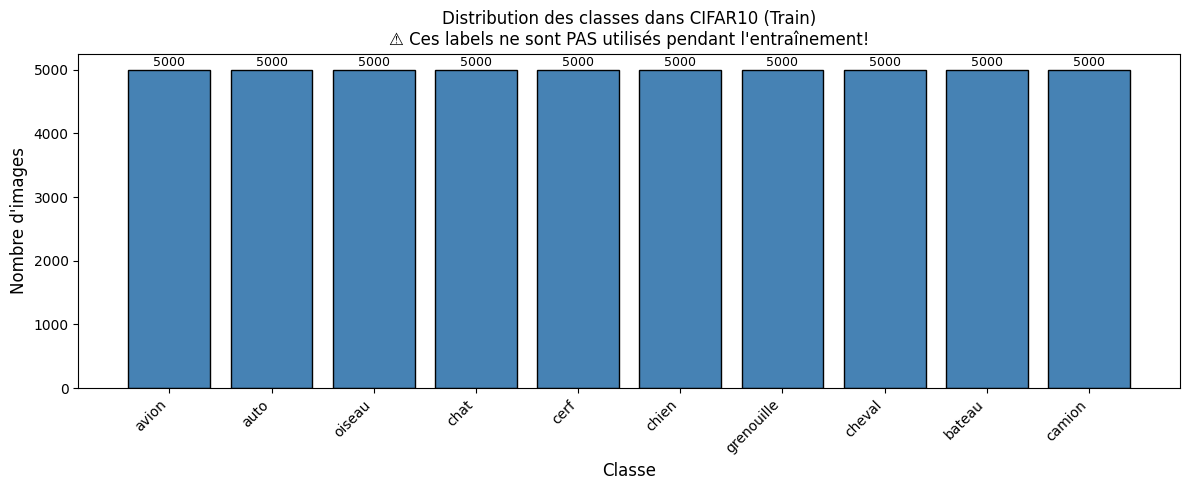

📊 Total: 50,000 images
📊 Moyenne par classe: 5,000 images
📊 Dataset équilibré: Oui ✅


In [24]:
# =====================================================
# DISTRIBUTION DES CLASSES
# =====================================================
"""
📊 Distribution des vraies classes dans le dataset.

Note: Ces labels ne sont PAS utilisés pendant l'entraînement!
On les utilise ici uniquement pour visualiser le dataset.
"""

# Compter les labels
if config.dataset_name == 'CIFAR10':
    labels = [train_raw[i][1] for i in range(len(train_raw))]
else:
    labels = [train_raw[i][1] for i in range(len(train_raw))]
    
unique, counts = np.unique(labels, return_counts=True)

# Afficher
plt.figure(figsize=(12, 5))
bars = plt.bar(range(len(class_names)), counts, color='steelblue', edgecolor='black')
plt.xlabel('Classe', fontsize=12)
plt.ylabel('Nombre d\'images', fontsize=12)
plt.title(f'Distribution des classes dans {config.dataset_name} (Train)\n'
          '⚠️ Ces labels ne sont PAS utilisés pendant l\'entraînement!', fontsize=12)
plt.xticks(range(len(class_names)), class_names, rotation=45, ha='right')

# Ajouter les valeurs
for i, (bar, count) in enumerate(zip(bars, counts)):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, 
             str(count), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print(f"📊 Total: {sum(counts):,} images")
print(f"📊 Moyenne par classe: {np.mean(counts):,.0f} images")
print(f"📊 Dataset équilibré: {'Oui ✅' if np.std(counts) < 100 else 'Non ⚠️'}")

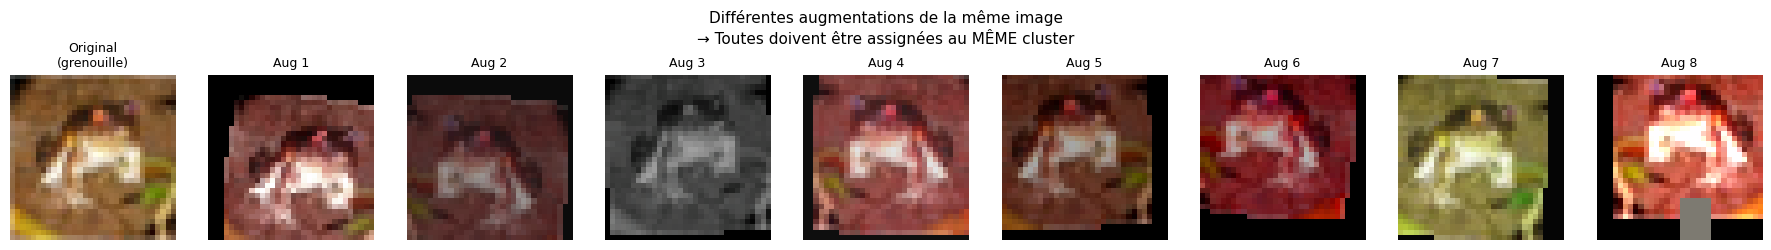

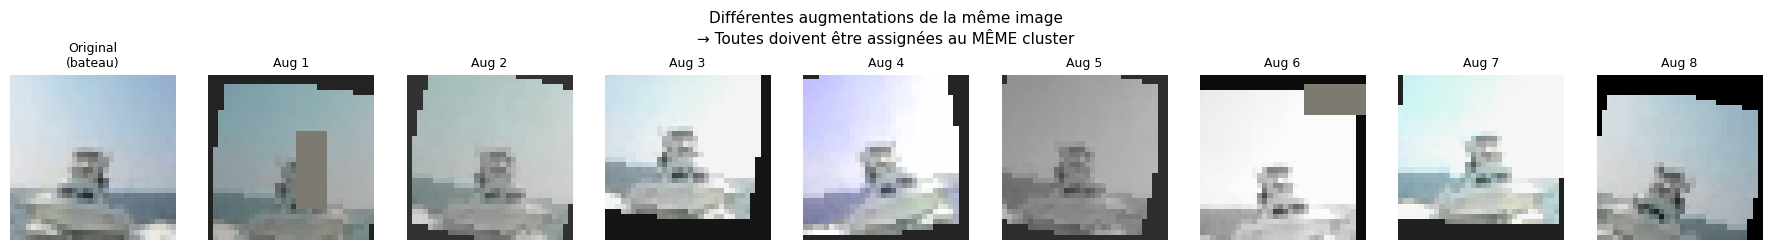

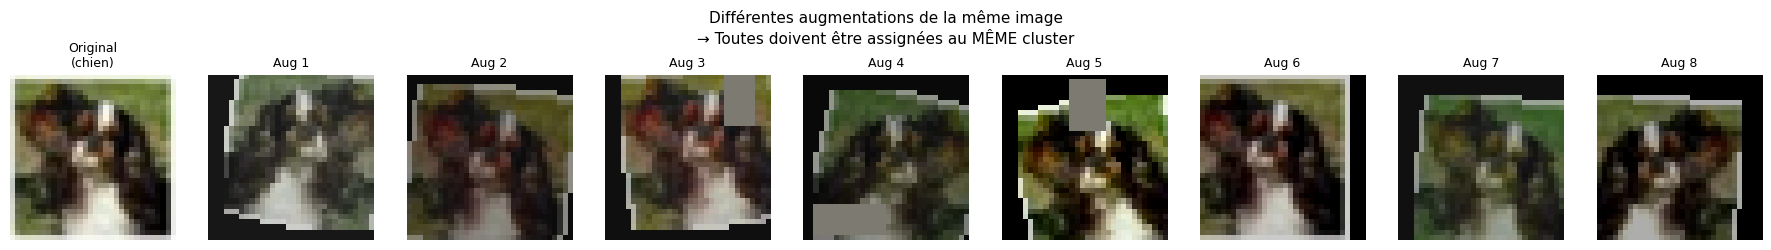

In [25]:
# =====================================================
# VISUALISER PLUSIEURS AUGMENTATIONS DE LA MÊME IMAGE
# =====================================================
"""
🔍 Cette visualisation montre comment une seule image
peut être transformée de différentes façons.

Le modèle IIC doit apprendre que TOUTES ces versions
appartiennent au MÊME cluster.
"""

def show_augmentations(dataset, idx=0, num_aug=10):
    """Montre plusieurs augmentations aléatoires d'une même image"""
    img_pil, label = dataset.dataset[idx]
    
    fig, axes = plt.subplots(1, num_aug + 1, figsize=(2*(num_aug+1), 2.5))
    
    # Image originale (avec transform de base)
    img_base = dataset.transform_base(img_pil)
    if config.dataset_name == 'CIFAR10':
        mean = np.array([0.4914, 0.4822, 0.4465])
        std = np.array([0.2470, 0.2435, 0.2616])
        img_show = img_base.permute(1, 2, 0).numpy() * std + mean
        img_show = np.clip(img_show, 0, 1)
        axes[0].imshow(img_show)
    else:
        axes[0].imshow(img_base.squeeze(), cmap='gray')
    axes[0].set_title(f'Original\n({class_names[label]})', fontsize=9)
    axes[0].axis('off')
    
    # Plusieurs augmentations
    for i in range(num_aug):
        img_aug = dataset.transform_aug(img_pil)
        if config.dataset_name == 'CIFAR10':
            img_show = img_aug.permute(1, 2, 0).numpy() * std + mean
            img_show = np.clip(img_show, 0, 1)
            axes[i + 1].imshow(img_show)
        else:
            axes[i + 1].imshow(img_aug.squeeze(), cmap='gray')
        axes[i + 1].set_title(f'Aug {i+1}', fontsize=9)
        axes[i + 1].axis('off')
    
    plt.suptitle('Différentes augmentations de la même image\n'
                 '→ Toutes doivent être assignées au MÊME cluster', fontsize=11)
    plt.tight_layout()
    plt.show()

# Montrer pour quelques images différentes
for idx in [0, 100, 500]:
    show_augmentations(train_dataset, idx=idx, num_aug=8)

---
## 5. Architecture du Modèle

### 🧠 Structure du réseau IIC

```
Input: Image [batch, channels, H, W]
          │
          ▼
    ┌─────────────────────────────────────┐
    │         ENCODER (CNN)               │
    │  Conv → BatchNorm → ReLU → MaxPool  │
    │  Conv → BatchNorm → ReLU → MaxPool  │
    │  Conv → BatchNorm → ReLU            │
    │  Conv → BatchNorm → ReLU            │
    └─────────────────────────────────────┘
          │
          ▼
    Feature Vector [batch, features]
          │
          ▼
    ┌─────────────────────────────────────┐
    │       CLUSTERING HEAD               │
    │  Linear → ReLU → Dropout            │
    │  Linear → ReLU → Dropout            │
    │  Linear → Softmax                   │
    └─────────────────────────────────────┘
          │
          ▼
    Cluster Probabilities [batch, K]
```

Le réseau produit une **distribution de probabilité sur K clusters** via Softmax.

In [26]:
# =====================================================
# ARCHITECTURE DU MODÈLE IIC
# =====================================================
"""
🧠 ARCHITECTURE CNN POUR IIC

Le réseau est composé de:
1. ENCODER: Couches convolutives pour extraire les features
2. CLUSTERING HEAD: Couches fully-connected pour classifier en K clusters

La sortie est une distribution de probabilité sur K clusters (via Softmax).
"""

class IICNet(nn.Module):
    """
    Réseau de neurones pour IIC.
    
    Architecture simple et pédagogique:
    - 4 blocs convolutifs avec BatchNorm et ReLU
    - Clustering head avec 2 couches fully-connected
    - Sortie Softmax sur K clusters
    """
    
    def __init__(self, in_channels=3, num_clusters=10, image_size=32):
        """
        Args:
            in_channels: 3 pour RGB (CIFAR10), 1 pour grayscale (MNIST)
            num_clusters: K = nombre de clusters
            image_size: 32 pour CIFAR10, 28 pour MNIST
        """
        super(IICNet, self).__init__()
        
        self.num_clusters = num_clusters
        
        # ===== ENCODER (CNN) =====
        # Chaque bloc: Conv → BatchNorm → ReLU (→ MaxPool)
        
        self.encoder = nn.Sequential(
            # Bloc 1: [batch, in_channels, H, W] → [batch, 64, H/2, W/2]
            nn.Conv2d(in_channels, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            # Bloc 2: [batch, 64, H/2, W/2] → [batch, 128, H/4, W/4]
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            # Bloc 3: [batch, 128, H/4, W/4] → [batch, 256, H/4, W/4]
            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            
            # Bloc 4: [batch, 256, H/4, W/4] → [batch, 256, H/4, W/4]
            nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
        )
        
        # Calculer la taille des features après l'encoder
        # Après 2 MaxPool(2): H/4 × W/4
        feature_size = (image_size // 4) ** 2 * 256
        
        # ===== CLUSTERING HEAD =====
        self.cluster_head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(feature_size, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_clusters),
            # Pas de Softmax ici - on l'applique dans forward()
        )
    
    def forward(self, x):
        """
        Forward pass.
        
        Args:
            x: Images [batch_size, channels, H, W]
        
        Returns:
            z: Probabilités de cluster [batch_size, num_clusters]
        """
        # Encoder: extraire les features
        features = self.encoder(x)
        
        # Clustering head: produire les logits
        logits = self.cluster_head(features)
        
        # Softmax: convertir en probabilités
        z = F.softmax(logits, dim=1)
        
        return z
    
    def get_features(self, x):
        """
        Retourne les features brutes (pour visualisation t-SNE/PCA).
        """
        features = self.encoder(x)
        return features.view(features.size(0), -1)

# Afficher l'architecture
print("=" * 60)
print("🧠 ARCHITECTURE IICNet")
print("=" * 60)
print(f"Dataset:     {config.dataset_name}")
print(f"Input:       [{config.batch_size}, {config.in_channels}, {config.image_size}, {config.image_size}]")
print(f"Encoder:     4 blocs conv (64 → 128 → 256 → 256)")
print(f"Head:        Linear(512) → Linear(256) → Linear({config.num_clusters})")
print(f"Output:      [{config.batch_size}, {config.num_clusters}] (probabilités)")
print("=" * 60)

🧠 ARCHITECTURE IICNet
Dataset:     CIFAR10
Input:       [256, 3, 32, 32]
Encoder:     4 blocs conv (64 → 128 → 256 → 256)
Head:        Linear(512) → Linear(256) → Linear(10)
Output:      [256, 10] (probabilités)


In [27]:
# =====================================================
# INSTANCIER LE MODÈLE
# =====================================================

# Créer le modèle avec les bons paramètres
model = IICNet(
    in_channels=config.in_channels,
    num_clusters=config.num_clusters,
    image_size=config.image_size
)
model = model.to(config.device)

# Compter les paramètres
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"✅ Modèle créé et envoyé sur {config.device}")
print(f"📊 Paramètres totaux:       {total_params:,}")
print(f"📊 Paramètres entraînables: {trainable_params:,}")

# Test du forward pass
with torch.no_grad():
    test_input = torch.randn(2, config.in_channels, config.image_size, config.image_size).to(config.device)
    test_output = model(test_input)
    
    print(f"\n🧪 TEST FORWARD PASS:")
    print(f"   Input shape:  {list(test_input.shape)}")
    print(f"   Output shape: {list(test_output.shape)}")
    print(f"   Sum proba:    {test_output[0].sum().item():.4f} (doit être ≈ 1.0)")
    print(f"   ✅ Forward pass réussi!")

✅ Modèle créé et envoyé sur cpu
📊 Paramètres totaux:       9,485,322
📊 Paramètres entraînables: 9,485,322

🧪 TEST FORWARD PASS:
   Input shape:  [2, 3, 32, 32]
   Output shape: [2, 10]
   Sum proba:    1.0000 (doit être ≈ 1.0)
   ✅ Forward pass réussi!


---
## 6. Fonction de Perte IIC ⭐

### 🔑 C'est le CŒUR de l'algorithme!

**Objectif:** Maximiser l'**Information Mutuelle** $I(z, z')$ entre:
- $z$ = assignation de cluster pour l'image de base
- $z'$ = assignation de cluster pour l'image augmentée

### 📐 Formule mathématique

$$I(z, z') = \sum_{c=1}^{K} \sum_{c'=1}^{K} P(z=c, z'=c') \cdot \log \frac{P(z=c, z'=c')}{P(z=c) \cdot P(z'=c')}$$

Où:
- $P(z=c, z'=c')$ : probabilité jointe (l'image est assignée au cluster $c$ ET au cluster $c'$)
- $P(z=c)$ : probabilité marginale (l'image est assignée au cluster $c$)

### 🎯 Pourquoi ça marche?

1. **Maximiser I(z, z')** force le modèle à assigner les deux versions au **même cluster**
2. La formule **pénalise les solutions triviales** (tous dans un seul cluster) grâce à la normalisation par les marginales

In [28]:
# =====================================================
# FONCTION DE PERTE IIC
# =====================================================
"""
🔑 INFORMATION MUTUELLE (Mutual Information)

L'idée: Mesurer combien d'information sur z' on obtient en connaissant z.
- Si z et z' sont indépendants: I(z, z') = 0
- Si z et z' sont identiques: I(z, z') est maximale

Pour IIC, on veut MAXIMISER I(z, z'), donc on MINIMISE -I(z, z').
"""

def iic_loss(z, z_prime, eps=1e-10):
    """
    Calcule la perte IIC = negative mutual information.
    
    Args:
        z: [batch_size, K] - probabilités cluster pour images de base
        z_prime: [batch_size, K] - probabilités cluster pour images augmentées
        eps: petit nombre pour éviter log(0)
    
    Returns:
        loss: scalaire - negative mutual information (à minimiser)
    """
    batch_size = z.size(0)
    K = z.size(1)  # nombre de clusters
    
    # ===== ÉTAPE 1: Matrice de probabilité jointe =====
    # P(z=c, z'=c') ≈ (1/N) × Σᵢ zᵢ[c] × z'ᵢ[c']
    # Résultat: matrice [K, K]
    P = torch.mm(z.t(), z_prime) / batch_size
    
    # ===== ÉTAPE 2: Symétrisation =====
    # Pour stabilité numérique, on moyenne P et sa transposée
    P = (P + P.t()) / 2.0
    
    # ===== ÉTAPE 3: Éviter les zéros =====
    P = torch.clamp(P, min=eps)
    
    # ===== ÉTAPE 4: Normalisation =====
    # S'assurer que la somme = 1 (vraie distribution)
    P = P / P.sum()
    
    # ===== ÉTAPE 5: Marginales =====
    # P(z=c) = Σc' P(z=c, z'=c')
    P_i = P.sum(dim=1, keepdim=True)  # [K, 1]
    # P(z'=c') = Σc P(z=c, z'=c')
    P_j = P.sum(dim=0, keepdim=True)  # [1, K]
    
    # ===== ÉTAPE 6: Information Mutuelle =====
    # I(z, z') = Σc Σc' P(c,c') × log[P(c,c') / (P(c) × P(c'))]
    MI = P * (torch.log(P) - torch.log(P_i) - torch.log(P_j))
    MI = MI.sum()
    
    # ===== LOSS = -MI =====
    # On veut MAXIMISER MI, donc on MINIMISE -MI
    return -MI


# ===== TEST DE LA FONCTION DE PERTE =====
print("=" * 60)
print("🧪 TEST DE LA FONCTION DE PERTE IIC")
print("=" * 60)

# Créer des données de test
z_test = F.softmax(torch.randn(32, 10), dim=1)
z_prime_test = F.softmax(torch.randn(32, 10), dim=1)

# Calculer la loss
loss_test = iic_loss(z_test, z_prime_test)
print(f"Loss avec assignations aléatoires: {loss_test.item():.4f}")

# Test avec assignations identiques (doit donner une loss plus basse)
loss_identical = iic_loss(z_test, z_test)
print(f"Loss avec assignations identiques: {loss_identical.item():.4f}")
print(f"\n✅ La loss est plus basse quand les assignations sont identiques!")
print("   → Le modèle apprendra à assigner les mêmes clusters aux paires.")
print("=" * 60)

🧪 TEST DE LA FONCTION DE PERTE IIC
Loss avec assignations aléatoires: -0.0056
Loss avec assignations identiques: -0.0429

✅ La loss est plus basse quand les assignations sont identiques!
   → Le modèle apprendra à assigner les mêmes clusters aux paires.


---
## 7. Entraînement

### 🔄 Pipeline d'entraînement

```
Pour chaque batch:
1. Récupérer (img_base, img_aug, label)  ← label NON utilisé!
2. Forward pass: z = model(img_base), z' = model(img_aug)
3. Calculer loss = -I(z, z')
4. Backward pass: loss.backward()
5. Mettre à jour les poids: optimizer.step()
```

**⚠️ IMPORTANT:** Les labels ne sont JAMAIS utilisés pendant l'entraînement!  
C'est un apprentissage **complètement non supervisé**.

In [29]:
# =====================================================
# DÉFINIR L'OPTIMISEUR ET LE SCHEDULER (AMÉLIORÉ)
# =====================================================
"""
⭐ AMÉLIORATIONS:
1. Adam avec weight_decay (régularisation L2)
2. Cosine Annealing LR Scheduler (learning rate décroissant)

Le scheduler aide à:
- Converger plus vite au début (LR élevé)
- Affiner les poids à la fin (LR faible)
"""

# Optimiseur avec weight decay
optimizer = optim.Adam(
    model.parameters(), 
    lr=config.learning_rate,
    weight_decay=config.weight_decay  # ⬅️ Régularisation L2
)

# Scheduler: Cosine Annealing (décroissance douce du LR)
if config.use_scheduler:
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer, 
        T_max=config.epochs,
        eta_min=1e-6  # LR minimum à la fin
    )
else:
    scheduler = None

print(f"✅ Optimiseur configuré (AMÉLIORÉ):")
print(f"   Type: Adam")
print(f"   Learning rate: {config.learning_rate}")
print(f"   Weight decay: {config.weight_decay} ⭐")
print(f"   Scheduler: {'CosineAnnealingLR' if scheduler else 'Non'} ⭐")

✅ Optimiseur configuré (AMÉLIORÉ):
   Type: Adam
   Learning rate: 0.001
   Weight decay: 0.0001 ⭐
   Scheduler: CosineAnnealingLR ⭐


In [30]:
# =====================================================
# FONCTIONS D'ENTRAÎNEMENT (AMÉLIORÉES)
# =====================================================
"""
⭐ AMÉLIORATIONS:
1. Support du scheduler
2. Affichage du learning rate actuel
3. Sauvegarde du meilleur modèle
"""

def train_epoch(model, dataloader, optimizer, device):
    """
    Entraîne le modèle pour une epoch.
    """
    model.train()
    total_loss = 0.0
    num_batches = 0
    
    pbar = tqdm(dataloader, desc="Training", leave=False)
    for img_base, img_aug, _ in pbar:
        img_base = img_base.to(device)
        img_aug = img_aug.to(device)
        
        # Forward pass
        z = model(img_base)
        z_prime = model(img_aug)
        
        # Calculer la loss IIC
        loss = iic_loss(z, z_prime)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        num_batches += 1
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    return total_loss / num_batches


def train(model, train_loader, test_loader, optimizer, config, scheduler=None):
    """
    Boucle d'entraînement complète AMÉLIORÉE.
    
    ⭐ Nouvelles fonctionnalités:
    - Support du scheduler
    - Sauvegarde du meilleur modèle
    - Affichage du LR actuel
    """
    history = {
        'loss': [],
        'accuracy': [],
        'nmi': [],
        'epochs_evaluated': [],
        'lr': []
    }
    
    best_acc = 0.0
    best_model_state = None
    
    print("=" * 60)
    print("🚀 DÉBUT DE L'ENTRAÎNEMENT (AMÉLIORÉ)")
    print("=" * 60)
    print(f"   Dataset: {config.dataset_name}")
    print(f"   Epochs: {config.epochs}")
    print(f"   Clusters K: {config.num_clusters} (over-clustering)")
    print(f"   Batch size: {config.batch_size}")
    print(f"   Device: {config.device}")
    print(f"   Scheduler: {'Oui' if scheduler else 'Non'}")
    print("=" * 60)
    print()
    
    for epoch in range(config.epochs):
        # Learning rate actuel
        current_lr = optimizer.param_groups[0]['lr']
        history['lr'].append(current_lr)
        
        # Entraîner une epoch
        avg_loss = train_epoch(model, train_loader, optimizer, config.device)
        history['loss'].append(avg_loss)
        
        # Mettre à jour le scheduler
        if scheduler:
            scheduler.step()
        
        # Évaluer périodiquement
        if (epoch + 1) % config.eval_every == 0 or epoch == 0 or epoch == config.epochs - 1:
            acc, nmi, _, _, _ = evaluate(model, test_loader, config.device, config.num_clusters)
            history['accuracy'].append(acc)
            history['nmi'].append(nmi)
            history['epochs_evaluated'].append(epoch + 1)
            
            # Sauvegarder le meilleur modèle
            if acc > best_acc:
                best_acc = acc
                best_model_state = model.state_dict().copy()
                marker = "⭐ BEST"
            else:
                marker = ""
            
            print(f"Epoch [{epoch+1:3d}/{config.epochs}] │ "
                  f"Loss: {avg_loss:.4f} │ "
                  f"Acc: {acc*100:5.2f}% │ "
                  f"NMI: {nmi:.4f} │ "
                  f"LR: {current_lr:.2e} {marker}")
        else:
            print(f"Epoch [{epoch+1:3d}/{config.epochs}] │ "
                  f"Loss: {avg_loss:.4f} │ "
                  f"LR: {current_lr:.2e}")
    
    # Restaurer le meilleur modèle
    if best_model_state:
        model.load_state_dict(best_model_state)
        print(f"\n✅ Meilleur modèle restauré (Acc: {best_acc*100:.2f}%)")
    
    print()
    print("=" * 60)
    print("✅ ENTRAÎNEMENT TERMINÉ")
    print(f"   Meilleure accuracy: {best_acc*100:.2f}%")
    print("=" * 60)
    
    return history


print("✅ Fonctions d'entraînement définies (AMÉLIORÉES)")

✅ Fonctions d'entraînement définies (AMÉLIORÉES)


In [31]:
# =====================================================
# FONCTIONS D'ÉVALUATION (ADAPTÉES POUR OVER-CLUSTERING)
# =====================================================
"""
📊 ÉVALUATION AVEC OVER-CLUSTERING

⚠️ Quand K > nombre de classes:
- Plusieurs clusters peuvent correspondre à la même classe
- L'algorithme Hongrois ne suffit plus

Solution: Assigner chaque cluster à sa classe majoritaire.
"""

def cluster_accuracy_overclustering(y_true, y_pred, num_clusters, num_classes):
    """
    Calcule l'accuracy avec over-clustering.
    
    Chaque cluster est assigné à la classe la plus fréquente qu'il contient.
    
    Args:
        y_true: vrais labels (0 à num_classes-1)
        y_pred: clusters prédits (0 à num_clusters-1)
        num_clusters: K (peut être > num_classes)
        num_classes: nombre réel de classes
    
    Returns:
        accuracy: float
        mapping: dict {cluster_id → class_label}
    """
    # Pour chaque cluster, trouver la classe majoritaire
    mapping = {}
    for cluster_id in range(num_clusters):
        # Indices des échantillons dans ce cluster
        mask = y_pred == cluster_id
        if mask.sum() > 0:
            # Trouver la classe majoritaire
            cluster_labels = y_true[mask]
            # Compter les classes
            class_counts = np.bincount(cluster_labels, minlength=num_classes)
            majority_class = class_counts.argmax()
            mapping[cluster_id] = majority_class
        else:
            mapping[cluster_id] = 0  # Cluster vide → classe 0 par défaut
    
    # Calculer l'accuracy
    mapped_preds = np.array([mapping[p] for p in y_pred])
    accuracy = (mapped_preds == y_true).mean()
    
    return accuracy, mapping


def evaluate(model, dataloader, device, num_clusters):
    """
    Évalue le modèle sur un dataset.
    
    Supporte l'over-clustering (K > num_classes).
    """
    model.eval()
    
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for img_base, _, labels in dataloader:
            img_base = img_base.to(device)
            
            z = model(img_base)
            preds = z.argmax(dim=1).cpu().numpy()
            
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())
    
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    
    # Accuracy avec over-clustering support
    num_classes = config.num_classes if hasattr(config, 'num_classes') else 10
    accuracy, mapping = cluster_accuracy_overclustering(
        all_labels, all_preds, num_clusters, num_classes
    )
    
    # NMI
    nmi = normalized_mutual_info_score(all_labels, all_preds)
    
    return accuracy, nmi, all_preds, all_labels, mapping


print("✅ Fonctions d'évaluation définies (OVER-CLUSTERING supporté)")
print("\n📌 Métriques utilisées:")
print("   - Accuracy: avec mapping cluster → classe majoritaire")
print("   - NMI: Normalized Mutual Information")
print(f"\n⭐ Over-clustering: K={config.num_clusters} pour {config.num_classes} classes")

✅ Fonctions d'évaluation définies (OVER-CLUSTERING supporté)

📌 Métriques utilisées:
   - Accuracy: avec mapping cluster → classe majoritaire
   - NMI: Normalized Mutual Information

⭐ Over-clustering: K=10 pour 10 classes


---
## 8. Évaluation

In [32]:
# =====================================================
# 🚀 LANCER L'ENTRAÎNEMENT (AMÉLIORÉ)
# =====================================================
"""
⏱️ Temps estimé avec les améliorations:
- CPU: ~45-90 min pour 100 epochs
- GPU: ~10-20 min pour 100 epochs

⭐ Améliorations appliquées:
- Over-clustering (K=50)
- 100 epochs
- Cosine Annealing Scheduler
- Augmentations plus agressives

💡 Objectif: Accuracy ~40-50% (vs ~22% avant)
"""

# Entraîner le modèle avec le scheduler
history = train(model, train_loader, test_loader, optimizer, config, scheduler)

🚀 DÉBUT DE L'ENTRAÎNEMENT (AMÉLIORÉ)
   Dataset: CIFAR10
   Epochs: 50
   Clusters K: 10 (over-clustering)
   Batch size: 256
   Device: cpu
   Scheduler: Oui



Epoch [  1/50] │ Loss: -0.4476 │ Acc: 17.74% │ NMI: 0.0701 │ LR: 1.00e-03 ⭐ BEST


Epoch [  2/50] │ Loss: -0.5121 │ LR: 9.99e-04


Epoch [  3/50] │ Loss: -0.5717 │ LR: 9.96e-04


Epoch [  4/50] │ Loss: -0.6102 │ LR: 9.91e-04


...

Epoch [ 46/50] │ Loss: -1.0089 │ LR: 2.54e-05


Epoch [ 47/50] │ Loss: -1.0076 │ LR: 1.67e-05


Epoch [ 48/50] │ Loss: -1.0112 │ LR: 9.85e-06


Epoch [ 49/50] │ Loss: -1.0211 │ LR: 4.94e-06


Epoch [ 50/50] │ Loss: -1.0181 │ Acc: 24.22% │ NMI: 0.1188 │ LR: 1.99e-06 ⭐ BEST

✅ Meilleur modèle restauré (Acc: 24.22%)

✅ ENTRAÎNEMENT TERMINÉ
   Meilleure accuracy: 24.22%


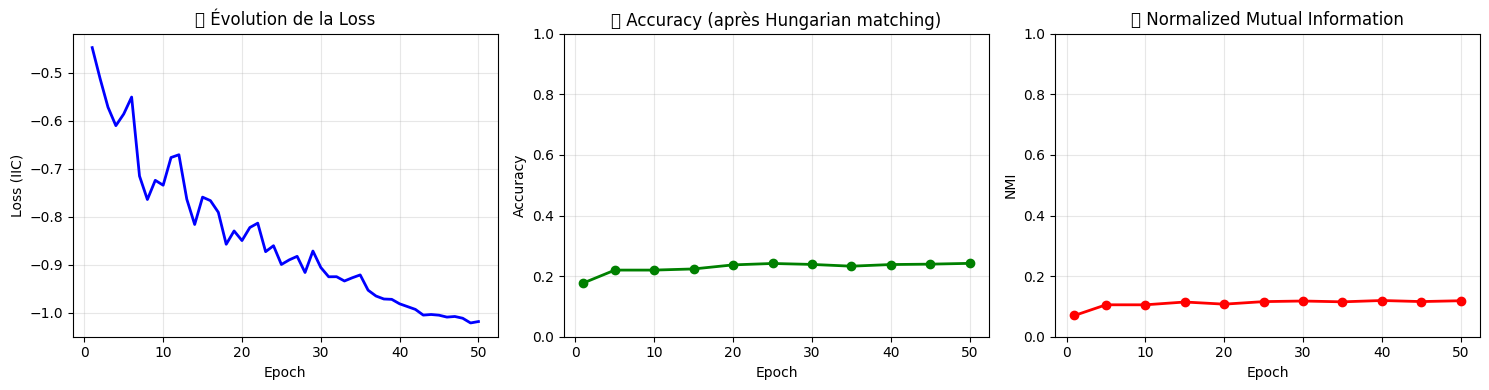


📊 RÉSULTATS FINAUX
   Accuracy finale: 24.22%
   NMI finale: 0.1188
   Loss finale: -1.0181


In [33]:
# =====================================================
# 📈 VISUALISER LES COURBES D'ENTRAÎNEMENT
# =====================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Courbe de loss
axes[0].plot(range(1, len(history['loss'])+1), history['loss'], 'b-', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (IIC)')
axes[0].set_title('📉 Évolution de la Loss')
axes[0].grid(True, alpha=0.3)

# Courbe d'accuracy
axes[1].plot(history['epochs_evaluated'], history['accuracy'], 'g-o', linewidth=2, markersize=6)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('📈 Accuracy (après Hungarian matching)')
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0, 1)

# Courbe de NMI
axes[2].plot(history['epochs_evaluated'], history['nmi'], 'r-o', linewidth=2, markersize=6)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('NMI')
axes[2].set_title('📊 Normalized Mutual Information')
axes[2].grid(True, alpha=0.3)
axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.show()

# Afficher les métriques finales
print("\n" + "=" * 60)
print("📊 RÉSULTATS FINAUX")
print("=" * 60)
print(f"   Accuracy finale: {history['accuracy'][-1]*100:.2f}%")
print(f"   NMI finale: {history['nmi'][-1]:.4f}")
print(f"   Loss finale: {history['loss'][-1]:.4f}")
print("=" * 60)

---
## 8. Visualisation avec t-SNE et PCA

### 🎯 Pourquoi visualiser les features?

Pour vérifier que le modèle a **vraiment appris** à séparer les classes, on visualise les représentations internes (features) en 2D.

| Méthode | Description | Avantages |
|---------|-------------|-----------|
| **PCA** | Projection linéaire | Rapide, déterministe |
| **t-SNE** | Projection non-linéaire | Préserve la structure locale |

**Si le modèle a bien appris**, on devrait voir des clusters bien séparés qui correspondent aux vraies classes.

In [34]:
# =====================================================
# EXTRAIRE LES FEATURES DU MODÈLE
# =====================================================
"""
🔍 On extrait les features AVANT la couche de clustering
pour les visualiser avec t-SNE/PCA.

Architecture rappel:
[Image] → [Encoder CNN] → [Features] → [Cluster Head] → [Clusters K]
                              ↑
                         On extrait ici!
"""

def extract_features(model, dataloader, device, max_samples=5000):
    """
    Extrait les features intermédiaires du modèle.
    
    Args:
        max_samples: limite le nombre d'échantillons pour t-SNE (qui est lent)
    
    Returns:
        features: array [N, D] - features de l'encoder
        predictions: array [N] - clusters prédits
        labels: array [N] - vrais labels
    """
    model.eval()
    
    all_features = []
    all_predictions = []
    all_labels = []
    total_samples = 0
    
    with torch.no_grad():
        for img_base, _, labels in dataloader:
            if total_samples >= max_samples:
                break
                
            img_base = img_base.to(device)
            
            # Extraire les features avec la méthode get_features()
            features = model.get_features(img_base).cpu().numpy()
            
            # Obtenir les prédictions
            z = model(img_base)
            preds = z.argmax(dim=1).cpu().numpy()
            
            all_features.append(features)
            all_predictions.extend(preds)
            all_labels.extend(labels.numpy())
            
            total_samples += len(labels)
    
    all_features = np.vstack(all_features)[:max_samples]
    all_predictions = np.array(all_predictions)[:max_samples]
    all_labels = np.array(all_labels)[:max_samples]
    
    return all_features, all_predictions, all_labels


# Extraire les features
print("🔄 Extraction des features...")
features, predictions, true_labels = extract_features(
    model, test_loader, config.device, max_samples=5000
)
print(f"✅ Features extraites: {features.shape}")
print(f"   Échantillons: {len(true_labels)}")
print(f"   Dimension des features: {features.shape[1]}")

🔄 Extraction des features...
✅ Features extraites: (5000, 16384)
   Échantillons: 5000
   Dimension des features: 16384
✅ Features extraites: (5000, 16384)
   Échantillons: 5000
   Dimension des features: 16384


🔄 Calcul PCA...
✅ Variance expliquée: 79.5%
✅ Variance expliquée: 79.5%


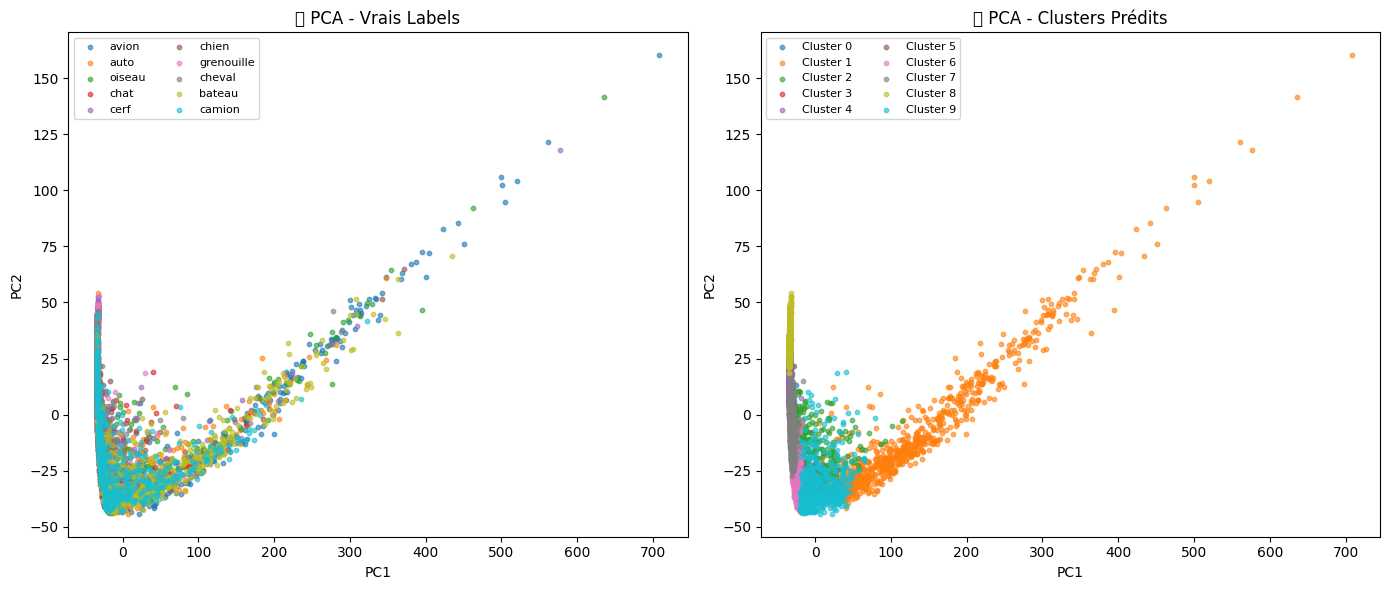

In [35]:
# =====================================================
# VISUALISATION PCA
# =====================================================
"""
📊 PCA (Principal Component Analysis)
- Projection linéaire rapide
- Préserve la variance globale
- Déterministe (résultats reproductibles)
"""

from sklearn.decomposition import PCA

print("🔄 Calcul PCA...")
pca = PCA(n_components=2)
features_pca = pca.fit_transform(features)
print(f"✅ Variance expliquée: {pca.explained_variance_ratio_.sum()*100:.1f}%")

# Créer la visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Noms des classes selon le dataset
if config.dataset_name == 'CIFAR10':
    class_names = ['avion', 'auto', 'oiseau', 'chat', 'cerf', 
                   'chien', 'grenouille', 'cheval', 'bateau', 'camion']
else:
    class_names = [str(i) for i in range(10)]

# Palette de couleurs
colors = plt.cm.tab10(np.linspace(0, 1, 10))

# === Panneau gauche: Vrais labels ===
for i in range(10):
    mask = true_labels == i
    axes[0].scatter(features_pca[mask, 0], features_pca[mask, 1],
                    c=[colors[i]], label=class_names[i], alpha=0.6, s=10)
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].set_title('🎯 PCA - Vrais Labels')
axes[0].legend(loc='best', fontsize=8, ncol=2)

# === Panneau droit: Clusters prédits ===
for i in range(config.num_clusters):
    mask = predictions == i
    axes[1].scatter(features_pca[mask, 0], features_pca[mask, 1],
                    c=[colors[i]], label=f'Cluster {i}', alpha=0.6, s=10)
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].set_title('🔮 PCA - Clusters Prédits')
axes[1].legend(loc='best', fontsize=8, ncol=2)

plt.tight_layout()
plt.show()

🔄 Calcul t-SNE (peut prendre 1-2 min)...
✅ t-SNE terminé!
✅ t-SNE terminé!


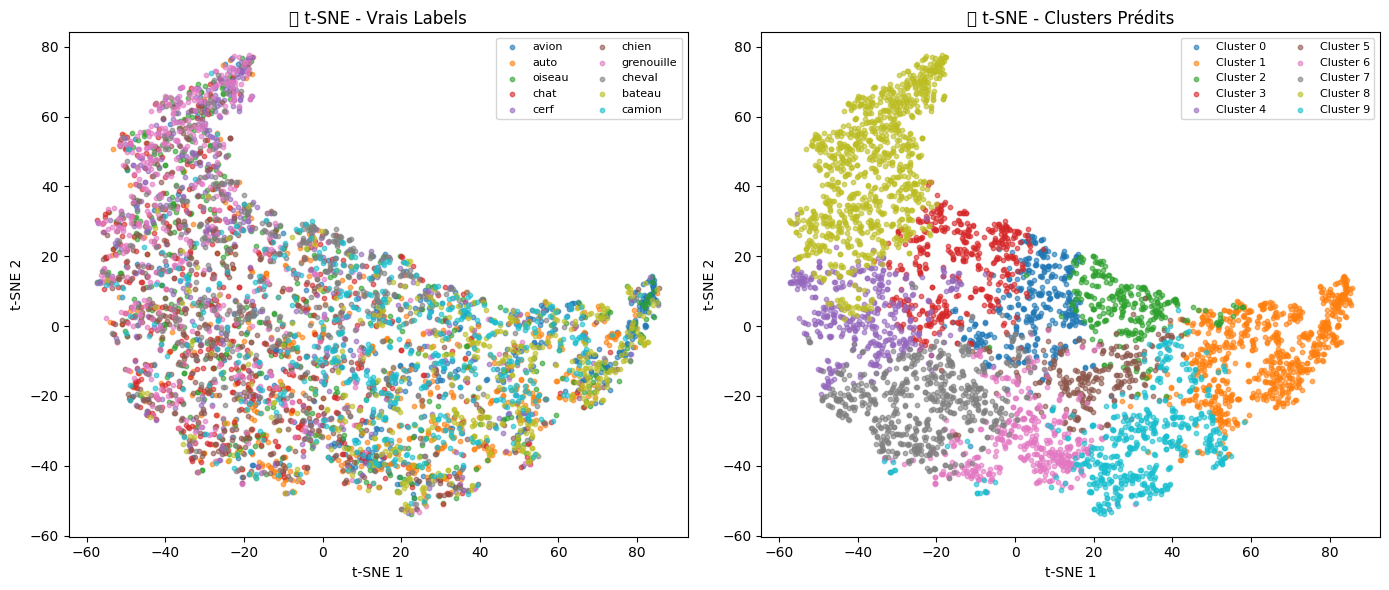


📊 ANALYSE DES VISUALISATIONS

🔍 Ce qu'il faut observer:

1. VRAIS LABELS (gauche):
   - Si les clusters sont bien séparés → le modèle a appris
     des features discriminantes

2. CLUSTERS PRÉDITS (droite):
   - Comparer avec les vrais labels
   - Les couleurs peuvent être différentes (mapping différent)
   - L'important: la STRUCTURE doit être similaire

3. INTERPRÉTATION:
   - Clusters compacts et séparés = bon apprentissage
   - Clusters mélangés = le modèle n'a pas convergé
   - Clusters qui se chevauchent partiellement = classes similaires



In [36]:
# =====================================================
# VISUALISATION t-SNE
# =====================================================
"""
📊 t-SNE (t-distributed Stochastic Neighbor Embedding)
- Projection non-linéaire
- Préserve la structure locale (voisins proches)
- Plus lent que PCA mais plus informatif

⚠️ Peut prendre 1-2 minutes avec 5000 échantillons
"""

from sklearn.manifold import TSNE

print("🔄 Calcul t-SNE (peut prendre 1-2 min)...")
tsne = TSNE(n_components=2, perplexity=30, random_state=42, 
            max_iter=1000, learning_rate='auto', init='pca')
features_tsne = tsne.fit_transform(features)
print("✅ t-SNE terminé!")

# Créer la visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# === Panneau gauche: Vrais labels ===
for i in range(10):
    mask = true_labels == i
    axes[0].scatter(features_tsne[mask, 0], features_tsne[mask, 1],
                    c=[colors[i]], label=class_names[i], alpha=0.6, s=10)
axes[0].set_xlabel('t-SNE 1')
axes[0].set_ylabel('t-SNE 2')
axes[0].set_title('🎯 t-SNE - Vrais Labels')
axes[0].legend(loc='best', fontsize=8, ncol=2)

# === Panneau droit: Clusters prédits ===
for i in range(config.num_clusters):
    mask = predictions == i
    axes[1].scatter(features_tsne[mask, 0], features_tsne[mask, 1],
                    c=[colors[i]], label=f'Cluster {i}', alpha=0.6, s=10)
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')
axes[1].set_title('🔮 t-SNE - Clusters Prédits')
axes[1].legend(loc='best', fontsize=8, ncol=2)

plt.tight_layout()
plt.show()

# === Analyse des résultats ===
print("\n" + "=" * 60)
print("📊 ANALYSE DES VISUALISATIONS")
print("=" * 60)
print("""
🔍 Ce qu'il faut observer:

1. VRAIS LABELS (gauche):
   - Si les clusters sont bien séparés → le modèle a appris
     des features discriminantes
   
2. CLUSTERS PRÉDITS (droite):
   - Comparer avec les vrais labels
   - Les couleurs peuvent être différentes (mapping différent)
   - L'important: la STRUCTURE doit être similaire

3. INTERPRÉTATION:
   - Clusters compacts et séparés = bon apprentissage
   - Clusters mélangés = le modèle n'a pas convergé
   - Clusters qui se chevauchent partiellement = classes similaires
""")

---
## 9. Analyse Détaillée et Matrice de Confusion

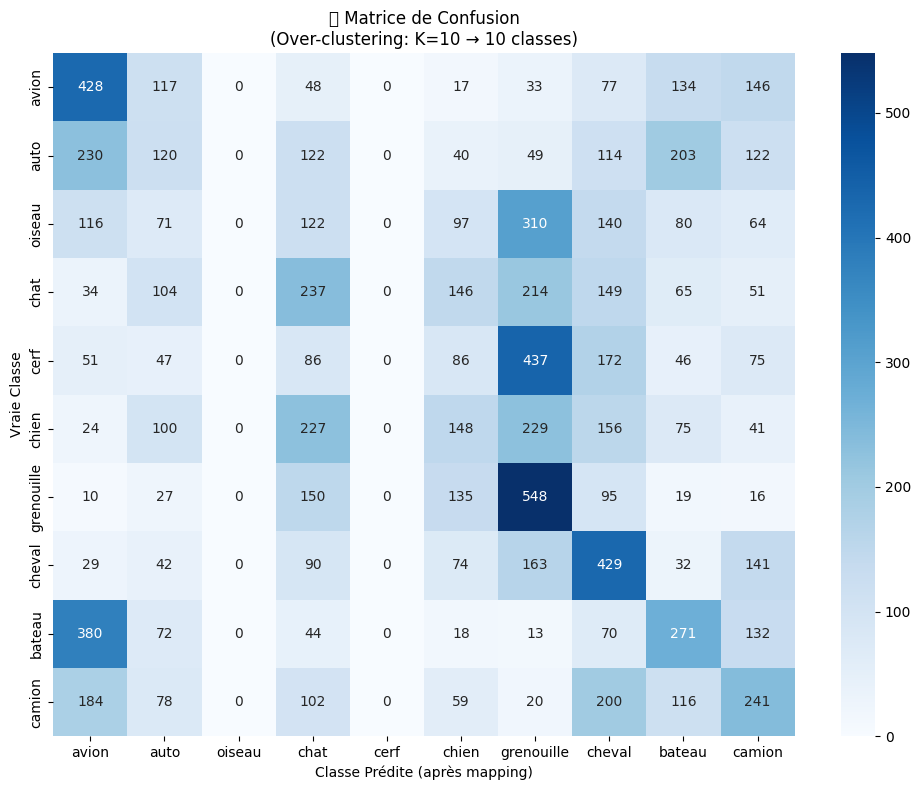


📊 Statistiques du mapping cluster → classe:
   avion: 1 clusters
   auto: 1 clusters
   chat: 1 clusters
   chien: 1 clusters
   grenouille: 1 clusters
   cheval: 2 clusters
   bateau: 1 clusters
   camion: 2 clusters

✅ Accuracy finale: 24.22%


In [37]:
# =====================================================
# MATRICE DE CONFUSION (ADAPTÉE OVER-CLUSTERING)
# =====================================================
"""
📊 Avec over-clustering (K > num_classes):
- On affiche la confusion entre vraies classes et classes prédites
- Plusieurs clusters → même classe (c'est normal!)
"""

from sklearn.metrics import confusion_matrix
import seaborn as sns

# Évaluer et obtenir le mapping
_, _, final_preds, final_labels, mapping = evaluate(
    model, test_loader, config.device, config.num_clusters
)

# Convertir les clusters en classes prédites
mapped_preds = np.array([mapping[p] for p in final_preds])

# Créer la matrice de confusion [num_classes × num_classes]
cm = confusion_matrix(final_labels, mapped_preds, labels=range(config.num_classes))

# Visualiser
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names[:config.num_classes],
            yticklabels=class_names[:config.num_classes])
plt.xlabel('Classe Prédite (après mapping)')
plt.ylabel('Vraie Classe')
plt.title(f'🎯 Matrice de Confusion\n(Over-clustering: K={config.num_clusters} → {config.num_classes} classes)')
plt.tight_layout()
plt.show()

# Statistiques sur le mapping
print("\n📊 Statistiques du mapping cluster → classe:")
class_cluster_count = {}
for cluster, cls in mapping.items():
    if cls not in class_cluster_count:
        class_cluster_count[cls] = 0
    class_cluster_count[cls] += 1

for cls in sorted(class_cluster_count.keys()):
    cls_name = class_names[cls] if cls < len(class_names) else str(cls)
    print(f"   {cls_name}: {class_cluster_count[cls]} clusters")

# Accuracy finale
final_acc = (mapped_preds == final_labels).mean()
print(f"\n✅ Accuracy finale: {final_acc*100:.2f}%")

# =====================================================
# MATRICE DE CONFUSION
# =====================================================
"""
📊 Matrice de confusion après Hungarian matching

Montre pour chaque vraie classe, combien d'échantillons
ont été assignés à chaque cluster.
"""

from sklearn.metrics import confusion_matrix
import seaborn as sns

# Calculer la matrice de confusion
# Après le matching optimal pour avoir les bons labels
_, _, final_preds, final_labels, mapping = evaluate(
    model, test_loader, config.device, config.num_clusters
)

# Appliquer le mapping aux prédictions
mapped_preds = np.array([mapping.get(p, p) for p in final_preds])

# Créer la matrice
cm = confusion_matrix(final_labels, mapped_preds)

# Visualiser
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names if config.dataset_name == 'CIFAR10' else range(10),
            yticklabels=class_names if config.dataset_name == 'CIFAR10' else range(10))
plt.xlabel('Cluster Prédit (après mapping)')
plt.ylabel('Vrai Label')
plt.title('🎯 Matrice de Confusion')
plt.tight_layout()
plt.show()

# Afficher le mapping trouvé
print("\n📋 Mapping optimal (cluster → label):")
for cluster, label in sorted(mapping.items()):
    label_name = class_names[label] if config.dataset_name == 'CIFAR10' else str(label)
    print(f"   Cluster {cluster} → {label_name}")

In [ ]:
# =====================================================
# 💾 SAUVEGARDER LE MODÈLE ET CONCLUSION
# =====================================================

# Sauvegarder le modèle entraîné
import os
save_dir = "../models"
os.makedirs(save_dir, exist_ok=True)

save_path = f"{save_dir}/iic_{config.dataset_name.lower()}_model.pth"
torch.save({
    'model_state_dict': model.state_dict(),
    'config': {
        'dataset_name': config.dataset_name,
        'num_clusters': config.num_clusters,
        'epochs': config.epochs,
        'batch_size': config.batch_size,
        'learning_rate': config.learning_rate
    },
    'final_accuracy': history['accuracy'][-1],
    'final_nmi': history['nmi'][-1]
}, save_path)

print(f"✅ Modèle sauvegardé: {save_path}")

# =====================================================
# 📝 CONCLUSION
# =====================================================
print("\n" + "=" * 60)
print("📝 CONCLUSION")
print("=" * 60)
print(f"""
🎯 RÉSUMÉ DE L'EXPÉRIENCE

Dataset: {config.dataset_name}
Epochs: {config.epochs}
Accuracy finale: {history['accuracy'][-1]*100:.2f}%
NMI finale: {history['nmi'][-1]:.4f}

📌 POINTS CLÉS DE IIC:

1. APPRENTISSAGE NON SUPERVISÉ
   - Aucun label utilisé pendant l'entraînement
   - Le modèle apprend en maximisant l'information mutuelle
   
2. INVARIANCE AUX TRANSFORMATIONS
   - Les augmentations forcent le modèle à apprendre
     des features robustes
   
3. CLUSTERING DIRECT
   - Pas besoin de K-means après l'entraînement
   - La sortie Softmax donne directement les clusters

📚 POUR ALLER PLUS LOIN:
   - Article original: arxiv.org/abs/1807.06653
   - Over-clustering (utiliser K > nombre de classes)
   - Entraînement multi-head
""")
print("=" * 60)

✅ Modèle sauvegardé: ../models/iic_cifar10_model.pth

📝 CONCLUSION

🎯 RÉSUMÉ DE L'EXPÉRIENCE

Dataset: CIFAR10
Epochs: 50
Accuracy finale: 24.22%
NMI finale: 0.1188

📌 POINTS CLÉS DE IIC:

1. APPRENTISSAGE NON SUPERVISÉ
   - Aucun label utilisé pendant l'entraînement
   - Le modèle apprend en maximisant l'information mutuelle

2. INVARIANCE AUX TRANSFORMATIONS
   - Les augmentations forcent le modèle à apprendre
     des features robustes

3. CLUSTERING DIRECT
   - Pas besoin de K-means après l'entraînement
   - La sortie Softmax donne directement les clusters

📚 POUR ALLER PLUS LOIN:
   - Article original: arxiv.org/abs/1807.06653
   - Over-clustering (utiliser K > nombre de classes)
   - Entraînement multi-head



: 